In [3]:
import pandas as pd

train_df = pd.read_csv("adult_income_train_preprocessed_cleaned.csv")
test_df = pd.read_csv("adult_income_test_preprocessed_cleaned.csv")

In [4]:
from sklearn.preprocessing import StandardScaler

X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]

X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Data scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Data scaling complete.
X_train_scaled shape: (39073, 89)
X_test_scaled shape: (9769, 89)


In [5]:
import pandas as pd
import numpy as np

df_train_tmp = pd.DataFrame(X_train_scaled.copy(), columns=X_train.columns)
df_train_tmp['income_target'] = y_train.values

df_high_class = df_train_tmp[df_train_tmp['income_target'] == 1].sample(500, random_state=42)
df_low_class = df_train_tmp[df_train_tmp['income_target'] == 0].sample(500, random_state=42)
ilp_cohort = pd.concat([df_high_class, df_low_class]).sample(frac=1, random_state=42).reset_index(drop=True)

def to_prolog_atom(value):
    return str(value).lower().replace(' ', '_').replace('-', '_').replace('.', '').replace('/', '_')

ilp_cohort['age_group'] = pd.cut(ilp_cohort['age'], bins=[-np.inf, -0.5, 0.5, np.inf], labels=['young', 'middle_aged', 'senior']).astype(str)
ilp_cohort['work_hours'] = pd.cut(ilp_cohort['hours-per-week'], bins=[-np.inf, -0.1, 0.1, np.inf], labels=['part_time', 'full_time', 'overtime']).astype(str)
ilp_cohort['education_tier'] = pd.cut(ilp_cohort['education-num'], bins=[-np.inf, 0.0, 1.0, np.inf], labels=['secondary', 'undergraduate', 'postgraduate']).astype(str)

for col in ['age_group', 'work_hours', 'education_tier']:
    ilp_cohort[col] = ilp_cohort[col].apply(to_prolog_atom)

In [6]:
positive_facts = []
negative_facts = []
background_knowledge_predicates = []

for idx, row in ilp_cohort.iterrows():
    individual_id = f"ind_{idx}"


    if row['income_target'] == 1:
        positive_facts.append(f"high_income({individual_id}).")
    else:
        negative_facts.append(f"high_income({individual_id}).")


    background_knowledge_predicates.append(f"age_bracket({individual_id}, {row['age_group']}).")
    background_knowledge_predicates.append(f"employment_hours({individual_id}, {row['work_hours']}).")
    background_knowledge_predicates.append(f"education_level({individual_id}, {row['education_tier']}).")

with open("macLearn_adultIncomedataset.f", "w") as f:
    f.write("\n".join(positive_facts))
with open("macLearn_adultIncomedataset.n", "w") as f:
    f.write("\n".join(negative_facts))


aleph_configuration_header = """
:- modeh(1, high_income(+individual)).
:- modeb(*, age_bracket(+individual, #age_atom)).
:- modeb(*, employment_hours(+individual, #hours_atom)).
:- modeb(*, education_level(+individual, #edu_atom)).

:- determination(high_income/1, age_bracket/2).
:- determination(high_income/1, employment_hours/2).
:- determination(high_income/1, education_level/2).
"""

with open("macLearn_adultIncomedataset.b", "w") as f:
    f.write(aleph_configuration_header.strip() + "\n\n" + "\n".join(background_knowledge_predicates))

print("ILP Logic Files 'macLearn_adultIncomedataset.b', 'macLearn_adultIncomedataset.f', and 'macLearn_adultIncomedataset.n' generated successfully!")

ILP Logic Files 'macLearn_adultIncomedataset.b', 'macLearn_adultIncomedataset.f', and 'macLearn_adultIncomedataset.n' generated successfully!


```prolog
high_income(X) :-
    education_level(X, postgraduate),
    employment_hours(X, overtime),
    age_bracket(X, middle_aged).
```

In [7]:
prolog_rule_content = """
high_income(X) :-
    education_level(X, postgraduate),
    employment_hours(X, overtime),
    age_bracket(X, middle_aged).
"""

with open("high_income_rule.pl", "w") as f:
    f.write(prolog_rule_content)

print("Prolog rule saved to high_income_rule.pl")

Prolog rule saved to high_income_rule.pl


In [9]:

def to_prolog_atom(value):
    return str(value).lower().replace(' ', '_').replace('-', '_').replace('.', '').replace('/', '_')


df_test_tmp = test_df.copy()


df_test_tmp['age_group'] = pd.cut(df_test_tmp['age'], bins=[-np.inf, -0.5, 0.5, np.inf], labels=['young', 'middle_aged', 'senior']).astype(str)
df_test_tmp['work_hours'] = pd.cut(df_test_tmp['hours-per-week'], bins=[-np.inf, -0.1, 0.1, np.inf], labels=['part_time', 'full_time', 'overtime']).astype(str)
df_test_tmp['education_tier'] = pd.cut(df_test_tmp['education-num'], bins=[-np.inf, 0.0, 1.0, np.inf], labels=['secondary', 'undergraduate', 'postgraduate']).astype(str)

for col in ['age_group', 'work_hours', 'education_tier']:
    df_test_tmp[col] = df_test_tmp[col].apply(to_prolog_atom)
def predict_with_ilp_rule(row):
    condition1 = (row['education_tier'] == 'postgraduate')
    condition2 = (row['work_hours'] == 'overtime')
    condition3 = (row['age_group'] == 'middle_aged')
    return 1 if (condition1 and condition2 and condition3) else 0

ilp_predictions = df_test_tmp.apply(predict_with_ilp_rule, axis=1)


ilp_accuracy = np.mean(ilp_predictions == df_test_tmp['income_encoded'])

print(f"Simulated ILP Rule Accuracy on Test Data: {ilp_accuracy * 100:.2f}%")


Simulated ILP Rule Accuracy on Test Data: 77.56%


In [10]:
from sklearn.metrics import classification_report, roc_auc_score, balanced_accuracy_score

y_true = df_test_tmp['income_encoded']

y_pred = ilp_predictions

print("\n--- Classification Report (ILP Rule) ---")
print(classification_report(y_true, y_pred))

balanced_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy: {balanced_acc * 100:.2f}%")

roc_auc = roc_auc_score(y_true, y_pred) # For binary classification, y_pred can be the hard predictions
print(f"ROC-AUC Score: {roc_auc:.2f}")


--- Classification Report (ILP Rule) ---
              precision    recall  f1-score   support

           0       0.78      0.98      0.87      7431
           1       0.66      0.13      0.22      2338

    accuracy                           0.78      9769
   macro avg       0.72      0.55      0.54      9769
weighted avg       0.75      0.78      0.71      9769

Balanced Accuracy: 55.47%
ROC-AUC Score: 0.55


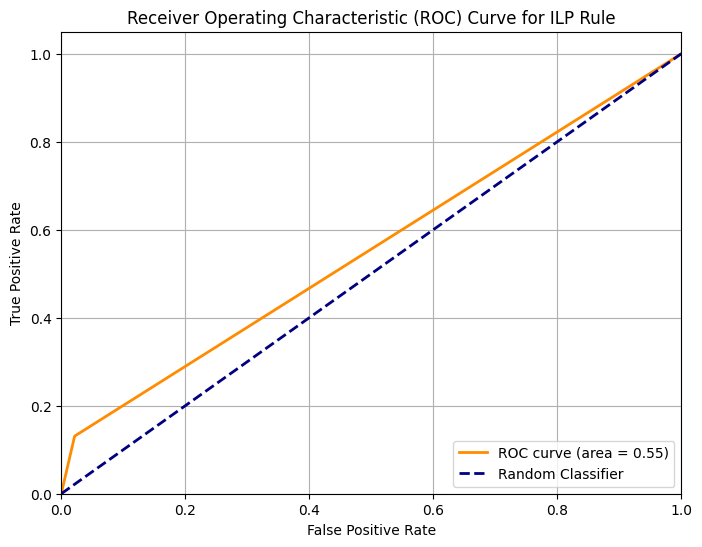

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for ILP Rule')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

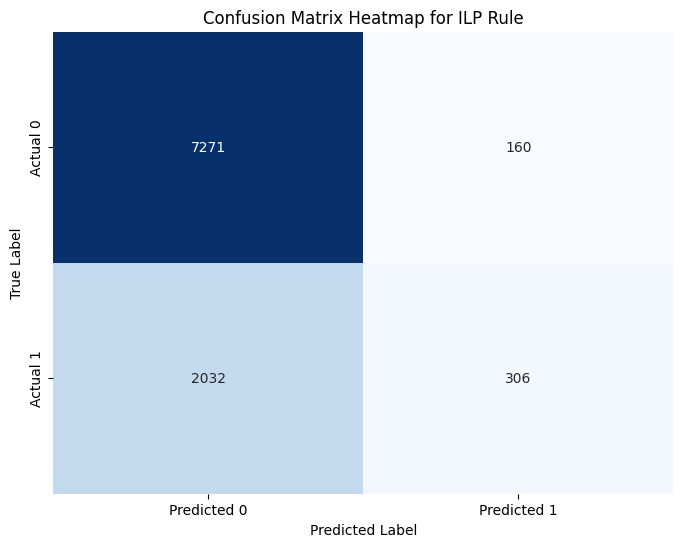

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap for ILP Rule')
plt.show()

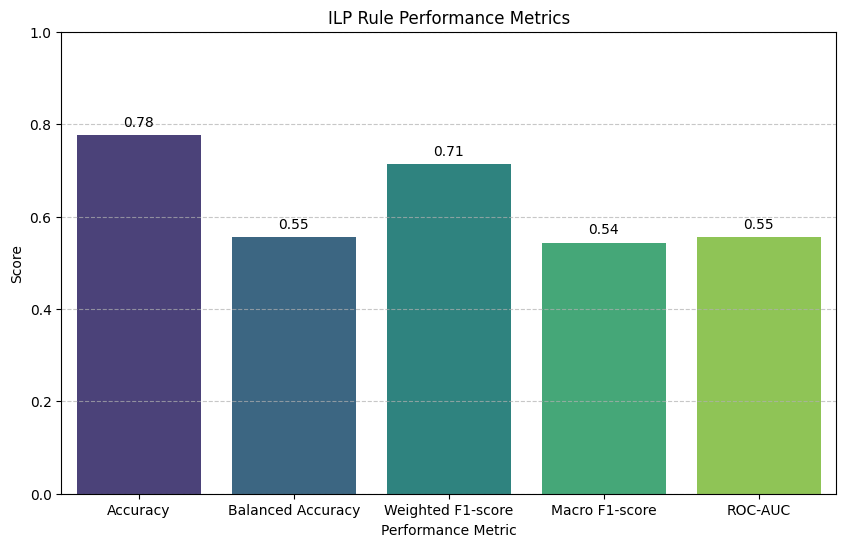

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, f1_score

accuracy = ilp_accuracy

macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

metrics_data = {
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Weighted F1-score', 'Macro F1-score', 'ROC-AUC'],
    'Value': [accuracy, balanced_acc, weighted_f1, macro_f1, roc_auc]
}

df_metrics = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', data=df_metrics, palette='viridis', hue='Metric', legend=False)
plt.ylim(0, 1)
plt.title('ILP Rule Performance Metrics')
plt.ylabel('Score')
plt.xlabel('Performance Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for index, row in df_metrics.iterrows():
    plt.text(index, row['Value'] + 0.02, f"{row['Value']:.2f}", color='black', ha="center")

plt.show()

In [14]:

df_scores_csv = df_metrics.copy()
df_scores_csv['Value'] = df_scores_csv['Value'] * 100
df_scores_csv.to_csv('performance_scores.csv', index=False)

print("Performance scores saved to 'AdultIncome_ILP_performance_scores.csv' (multiplied by 100).")
print(df_scores_csv)

Performance scores saved to 'AdultIncome_ILP_performance_scores.csv' (multiplied by 100).
              Metric      Value
0           Accuracy  77.561675
1  Balanced Accuracy  55.467484
2  Weighted F1-score  71.326629
3     Macro F1-score  54.363442
4            ROC-AUC  55.467484
